In [1]:
%load_ext autoreload
%autoreload 2

import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

from scipy.optimize import curve_fit

from file_reading import read_exp_file
import lorentz_fit as lorentz

In [2]:
# len in meters
l = 0.02
b = 5e-3
d = 200e-6

g_a = 100e-6
g_d = 100e-6

# N / m**2
E = 98e9
# kg / m**3
rho = 8.5e3
v_upsilon = np.sqrt(E / rho)

# C_a = epsilon_0 * S / g_a

# m = rho * l * b * d

# F_0_theo = 1/2 * C_a * U**2 / g_a

ALPHA_N = [1.424987, 0.992249, 1.000198, 0.999994]

def get_alpha_n(n: int):
    if n > 3:
        return 1
    return ALPHA_N[n]

def calc_free_reed_eigenfrequency(n: int):
    alpha_n = get_alpha_n(n)
    nu = alpha_n * (2 * n + 1)**2 * np.pi * d * v_upsilon / (16 * np.sqrt(3) * l**2)
    return nu

target_freqs = [calc_free_reed_eigenfrequency(n) for n in range(4)]
print(target_freqs)
for i, freq in enumerate(target_freqs[1:]):
    print(f"nu_{i+1}/nu_0 = {freq / target_freqs[0]}")

target_freqs = target_freqs[:3]
lowest_harmonic = target_freqs[0]

[np.float64(274.25448868690813), np.float64(1718.723524709954), np.float64(4812.478834467755), np.float64(9430.53467494007)]
nu_1/nu_0 = 6.266892961128769
nu_2/nu_0 = 17.547493415729406
nu_3/nu_0 = 34.38607229399286


In [3]:
def phase_func(f, omega_0, gamma):
    omega = 2 * np.pi * f
    return np.arctan(gamma * omega / (omega_0**2 - omega**2))

In [ ]:
def plot_target_freq(ax, target_freq: float, target_freq_name, height=10):
    '''Plots a vertical line at `target_freq`.'''
    axes = ax.axis()
    ax.vlines(target_freq, -height, height, colors="tab:grey", linestyles="--", label=target_freq_name)
    ax.axis(axes)

def plot_freq_spectrum(fig, axs, data):
    (freq, A, A_err, phi, phi_err) = data
    # freq, A, A_err, phi, phi_err = freq[1:], A[1:], A_err[1:], phi[1:], phi_err[1:]
    X = A * np.cos(phi)
    Y = A * np.sin(phi)

    ax1, ax2, ax3 = axs[0], axs[1], axs[2]
    ax1.errorbar(freq, A, yerr=A_err)
    ax1.set_xlabel(r"$\nu$ / Hz")
    ax1.set_ylabel(r"$A$ / Vpp")
    ax1.set_title("Resonance Curve (Amplitude)")
    
    ax2.errorbar(freq, phi, yerr=phi_err)
    ax2.set_xlabel(r"$\nu$ / Hz")
    ax2.set_ylabel(r"$\phi$")
    ax2.set_title("Phase Shift")

    ax3.errorbar(freq, X, label="$X = A \\cos (\\phi)$")
    ax3.errorbar(freq, Y, label="$Y = A \\sin (\\phi)$")
    ax3.set_xlabel(r"$\nu$ / Hz")
    ax3.set_ylabel(r"Amplitude / Vpp")
    ax3.set_title("Waveform Chart")
    ax3.legend()

    return fig, axs


Success at finding fit parameters for target frequency 125.00 Hz.
f_0     = 0.26923119522537753 ± 0.0003886270824990998
omega_0 = 785.7375920924479 ± 0.003941483157716989
gamma   = -5.049173155947742 ± 0.009161562191730525
Resulting Q-factor: -155.61708181207405 ± -31022380.727943283


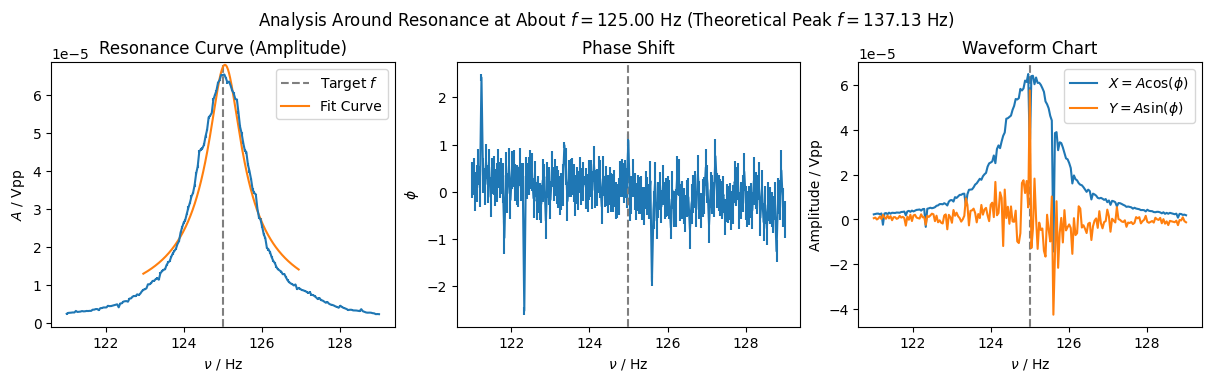

Success at finding fit parameters for target frequency 825.00 Hz.
f_0     = 0.09955658405230437 ± 0.0009158903972916114
omega_0 = -5183.763652061095 ± 0.06677646921755014
gamma   = 8.670962703702106 ± 0.1294621246357585
Resulting Q-factor: -597.8302328353765 ± -46408722.52438324


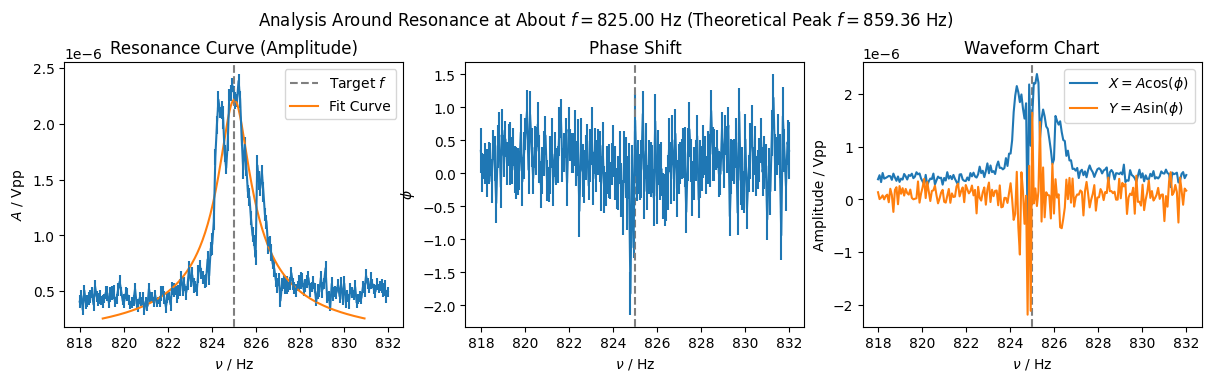

Success at finding fit parameters for target frequency 2406.24 Hz.
f_0     = 43.30613757736801 ± 62.251526676605806
omega_0 = 31.89113290399966 ± 14680422.584134897
gamma   = 24.818020146701727 ± 20057408.239993747
Resulting Q-factor: 1.2849990738780965 ± 1038509.5531567676


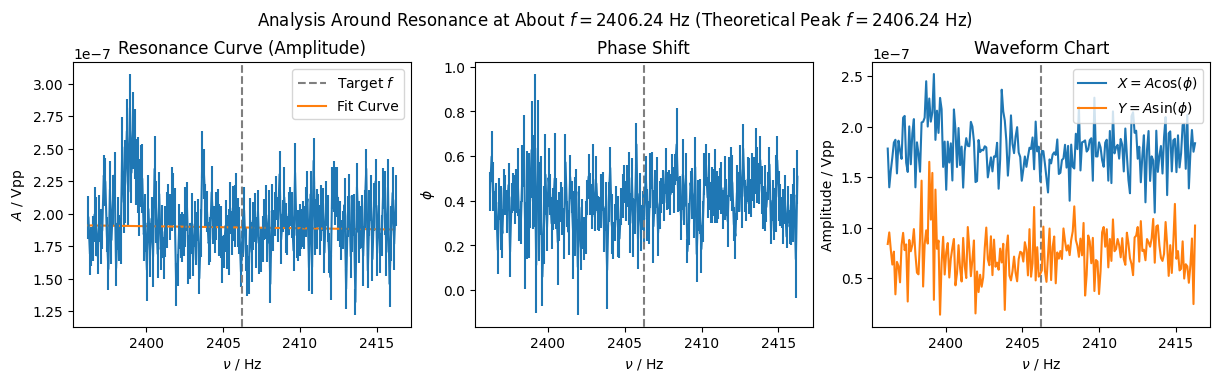

In [ ]:
locs = [
    "./Data/Final/Experiment_A/resonance0_data_0709_175609.txt",
    "./Data/Final/Experiment_A/resonance1_data_0709_190116.txt",
    "./Data/Final/Experiment_A/resonance2_data_0709_200623.txt"
]
p0s = [
    (0.002, 1, 1),
    (0.002, 1, 1),
    (0.002, 1, 1),
]
fit_limss = [
    (50, -50),
    (15, -15),
    (0, -1),
]

expA_fitparam_results: list[dict] = [{}] * len(locs)

for i, (loc, p0, fit_lims) in enumerate(zip(locs, p0s, fit_limss)):
    data, metadata = read_exp_file(loc, skip_data_rows=0)
    (freq, A, A_err, phi, phi_err) = data
    target_freq = metadata["target_freq"]
    theo_target_freq = metadata["theoretical_target_freq"]

    fig, axs = plt.subplots(1, 3, figsize=(4*3, 3.7), constrained_layout=True)
    plot_freq_spectrum(fig, axs, data)
    for ax in axs:
        plot_target_freq(ax, target_freq, 'Target $ f $')

    result_dict = {'target_freq': target_freq, 'theo_target_freq': theo_target_freq}
    # try to fit Lorentz curve
    # if not possible, catch error and continue
    try:
        params, params_err = lorentz.fit_analysis(
            axs[0],
            freq[fit_lims[0]:fit_lims[1]],
            A[fit_lims[0]:fit_lims[1]],
            A_err[fit_lims[0]:fit_lims[1]],
            p0
        )
        print(f"Success at finding fit parameters for target frequency {target_freq:.2f} Hz.")
        for param_name, param, param_err in zip(lorentz.FIT_PARAM_NAMES, params, params_err):
            result_dict[param_name] = param
            result_dict[param_name + '_err'] = param_err
            print(f'{param_name:<7} = {param} ± {param_err}')
        Q, Q_err = lorentz.calc_Q_factor(params, params_err)
        result_dict['fit_Q_factor'] = Q
        result_dict['fit_Q_err'] = Q_err
        print(f'Resulting Q-factor: {Q} ± {Q_err}')
        result_dict['params_list'] = params
        result_dict['params_err_list'] = params_err
    except RuntimeError as r_e:
        print(f"Finding fit parameters was not possible for target frequency {target_freq:.2f} Hz.")

    # append results to list (for later making into a pandas df)
    expA_fitparam_results[i] = result_dict

    axs[0].legend()
    fig.suptitle(f"Analysis Around Resonance at About $ f = {target_freq:.2f}$ Hz (Theoretical Peak $ f = {theo_target_freq:.2f} $ Hz)")
    plt.show()

Target Frequency: 125 Hz
dof: 196
chi2_val: 28667.168952050244
red_chi2_val: 146.261066081889
p-Value: 0.0


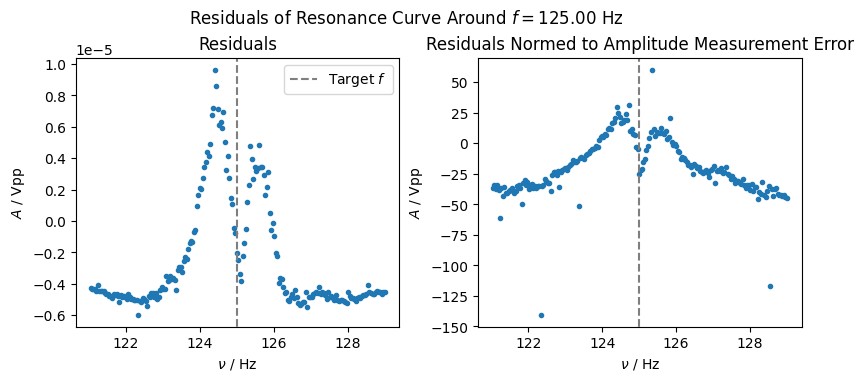

Target Frequency: 825 Hz
dof: 196
chi2_val: 1886.8147494576697
red_chi2_val: 9.626605864579947
p-Value: 7.81862983871297e-274


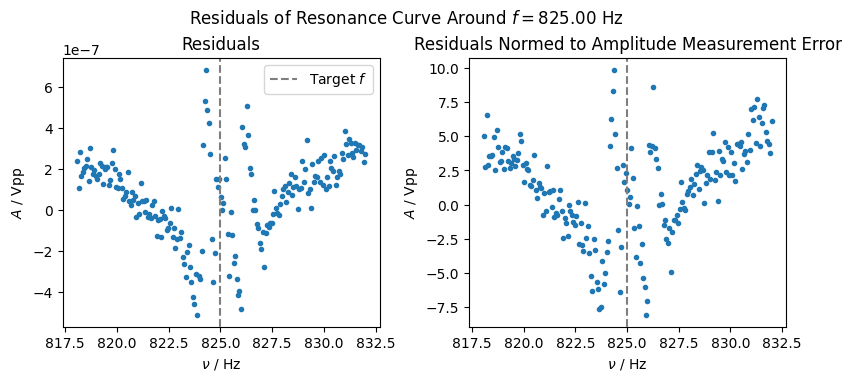

Target Frequency: 2406.2394172338777 Hz
dof: 196
chi2_val: 353.5211241585587
red_chi2_val: 1.8036792048906054
p-Value: 3.858819583403597e-11


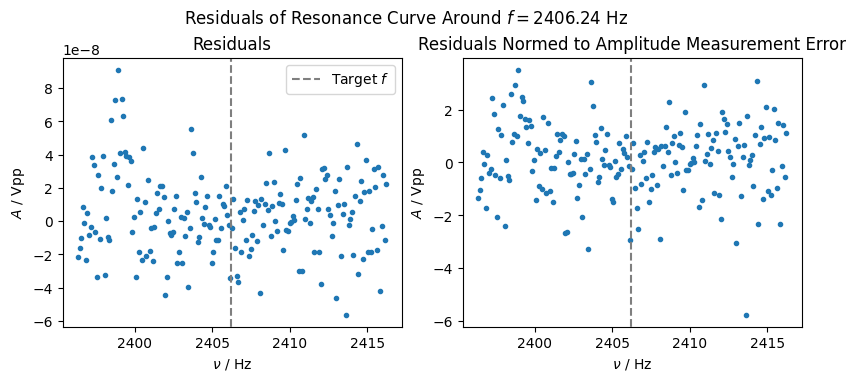

In [6]:
from scipy.stats import chi2

for i, (loc, fit_lims) in enumerate(zip(locs, fit_limss)):
    data, metadata = read_exp_file(loc)
    (freq, A, A_err, phi, phi_err) = data
    freq, A, A_err, phi, phi_err = freq[1:], A[1:], A_err[1:], phi[1:], phi_err[1:]
    target_freq = metadata["target_freq"]
    # theo_target_freq = metadata["theoretical_target_freq"]

    params = expA_fitparam_results[i]['params_list']
    params_err = expA_fitparam_results[i]['params_err_list']

    fig, axs = plt.subplots(1, 2, figsize=(4*2, 3.7), constrained_layout=True)

    # calculate residuals between data amplitude and fit curve predicted amplitude and plot
    residuals = A - lorentz.curve(freq, *params)
    axs[0].scatter(freq, residuals, marker='.')
    plot_target_freq(axs[0], target_freq, 'Target $ f $', height=200)
    axs[0].legend()
    axs[0].set_xlabel(r"$\nu$ / Hz")
    axs[0].set_ylabel(r"$A$ / Vpp")
    axs[0].set_title(f"Residuals")

    # same but scaled to errors
    axs[1].scatter(freq, residuals / A_err, marker='.')
    plot_target_freq(axs[1], target_freq, 'Target $ f $', height=200)
    axs[1].set_xlabel(r"$\nu$ / Hz")
    axs[1].set_ylabel(r"$A$ / Vpp")
    axs[1].set_title(f"Residuals Normed to Amplitude Measurement Error")

    fig.suptitle(f"Residuals of Resonance Curve Around $ f = {target_freq:.2f}$ Hz")

    chi2_val = np.sum(
        (
            (A[fit_lims[0]:fit_lims[1]] - lorentz.curve(freq[fit_lims[0]:fit_lims[1]], *params))
            / A_err[fit_lims[0]:fit_lims[1]]
        ) ** 2
    )
    dof = len(freq) - len(params)
    p_value = chi2.sf(chi2_val, dof)
    print(f"Target Frequency: {target_freq} Hz")
    print(f"dof: {dof}")
    print(f"chi2_val: {chi2_val}")
    print(f"red_chi2_val: {chi2_val / dof}")
    print(f"p-Value: {p_value}")

    plt.show()

In [7]:
# Für das reine Amplitudensignal ist 2δν durch den Frequenzabstand der Punkte gegeben, an denen die Amplitude vom
# Maximum auf den Wert Amax/√2 abgefallen ist

In [8]:
def find_fwhm_positions(x, y, epsilon: float):
    if len(x) != len(y):
        raise ValueError("Arrays have different sizes!")
    max = np.max(y)
    pos_max = np.argmax(y)

    xpoints_left = np.asarray(x)[:pos_max][
        np.abs(y[:pos_max] - max / np.sqrt(2)) < epsilon
    ]
    xpoints_right = np.asarray(x)[pos_max:][
        np.abs(y[pos_max:] - max / np.sqrt(2)) < epsilon
    ]
    return np.mean(xpoints_right) - np.mean(xpoints_left)

experimental_expA_Q_factors: list[dict] = []

for i, loc in enumerate(locs):
    data, metadata = read_exp_file(loc)
    (freq, A, A_err, phi, phi_err) = data
    freq, A, A_err, phi, phi_err = freq[1:], A[1:], A_err[1:], phi[1:], phi_err[1:]
    target_freq = metadata["target_freq"]
    theo_target_freq = metadata["theoretical_target_freq"]

    fwhm = find_fwhm_positions(freq, A, np.max(A_err)*2)

    Q = np.max(A) / fwhm
    Q_err = Q * A_err[np.argmax(A)] / np.max(A)

    print(f'Target Frequency: {target_freq:2f}')
    print(f"Q factor: {Q} ± {Q_err}")
    experimental_expA_Q_factors.append({
        "target_freq": target_freq,
        "exp_Q_factor": Q,
        "exp_Q_err": Q_err,
    })


expA_exp_df = pd.DataFrame(experimental_expA_Q_factors)
expA_fit_df = pd.DataFrame(expA_fitparam_results)
expA_fit_df.pop("params_list")
expA_fit_df.pop("params_err_list")
expA_df = pd.merge(expA_fit_df, expA_exp_df)

expA_df["Q_sigma_difference"] = np.abs(expA_df["fit_Q_factor"] - expA_df["exp_Q_factor"]) / np.sqrt((expA_df["fit_Q_err"])**2 + (expA_df["exp_Q_err"])**2)

display(expA_df)



Target Frequency: 125.000000
Q factor: 6.015998482051183e-05 ± 1.0491233894606239e-07
Target Frequency: 825.000000
Q factor: 1.940211956258157e-06 ± 4.996702912074086e-08
Target Frequency: 2406.239417
Q factor: 2.7860007138015418e-08 ± 2.5774849465292796e-09


,target_freq,theo_target_freq,f_0,f_0_err,omega_0,omega_0_err,gamma,gamma_err,fit_Q_factor,fit_Q_err,exp_Q_factor,exp_Q_err,Q_sigma_difference
0,125.000000,137.127244,0.269231,0.000389,785.737592,3.941483e-03,-5.049173,9.161562e-03,-155.617082,-3.102238e+07,6.015998e-05,1.049123e-07,0.000005
1,825.000000,859.361762,0.099557,0.000916,-5183.763652,6.677647e-02,8.670963,1.294621e-01,-597.830233,-4.640872e+07,1.940212e-06,4.996703e-08,0.000013
2,2406.239417,2406.239417,43.306138,62.251527,31.891133,1.468042e+07,24.818020,2.005741e+07,1.284999,1.038510e+06,2.786001e-08,2.577485e-09,0.000001
